# 02 — Feature Engineering

taking the raw OHLCV data and building features the model can actually use.  
also creating the label — did the stock go up the **next** day? (1 = yes, 0 = no)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

RAW_DIR       = '../data/raw'
PROCESSED_DIR = '../data/processed'
PLOTS_DIR     = '../plots'
os.makedirs(PROCESSED_DIR, exist_ok=True)

TICKERS = ['AAPL', 'MSFT', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

print('ready')

ready


## load raw data

In [2]:
def load_raw(ticker):
    fname = ticker.replace('.', '_') + '.csv'
    df = pd.read_csv(os.path.join(RAW_DIR, fname), index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df

raw = {t: load_raw(t) for t in TICKERS}

for t, df in raw.items():
    print(f'{t:15s}  {len(df)} rows  |  cols: {list(df.columns)}')

AAPL             2766 rows  |  cols: ['Close', 'High', 'Low', 'Open', 'Volume']
MSFT             2766 rows  |  cols: ['Close', 'High', 'Low', 'Open', 'Volume']
RELIANCE.NS      2716 rows  |  cols: ['Close', 'High', 'Low', 'Open', 'Volume']
TCS.NS           2716 rows  |  cols: ['Close', 'High', 'Low', 'Open', 'Volume']
HDFCBANK.NS      2716 rows  |  cols: ['Close', 'High', 'Low', 'Open', 'Volume']


## feature functions

keeping everything as ratios / normalised values so the model isn't affected by price scale differences between stocks.

In [3]:
def add_returns(df):
    """past returns over different windows"""
    df['ret_1d']  = df['Close'].pct_change(1)
    df['ret_3d']  = df['Close'].pct_change(3)
    df['ret_5d']  = df['Close'].pct_change(5)
    df['ret_10d'] = df['Close'].pct_change(10)
    return df


def add_ma_features(df):
    """price as a ratio of its moving averages — shows momentum direction"""
    for w in [5, 10, 20]:
        ma = df['Close'].rolling(w).mean()
        df[f'close_to_ma{w}'] = df['Close'] / ma
    return df


def add_volatility(df):
    """rolling std of daily returns — how choppy the stock is"""
    df['vol_5d']  = df['ret_1d'].rolling(5).std()
    df['vol_20d'] = df['ret_1d'].rolling(20).std()
    return df


def add_rsi(df, period=14):
    """
    Relative Strength Index — momentum oscillator, 0 to 100.
    below 30 = oversold, above 70 = overbought (classic thresholds).
    """
    delta    = df['Close'].diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean().replace(0, np.nan)
    rs       = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))
    return df


def add_volume_ratio(df):
    """today's volume vs 10-day average — high spikes often precede big moves"""
    df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(10).mean()
    return df


def add_label(df):
    """
    target = 1 if tomorrow's close > today's close, else 0.
    shift(-1) looks one day ahead — the last row becomes NaN and gets dropped.
    """
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    return df


print('functions defined')

functions defined


## build feature dataframes

running all features on each ticker and saving to `data/processed/`.

In [4]:
FEATURE_COLS = [
    'ret_1d', 'ret_3d', 'ret_5d', 'ret_10d',
    'close_to_ma5', 'close_to_ma10', 'close_to_ma20',
    'vol_5d', 'vol_20d',
    'rsi',
    'vol_ratio',
]

processed = {}

for ticker, df in raw.items():
    df = df.copy()

    df = add_returns(df)
    df = add_ma_features(df)
    df = add_volatility(df)
    df = add_rsi(df)
    df = add_volume_ratio(df)
    df = add_label(df)

    # keep only features + target, drop rows with NaN from rolling windows
    df = df[FEATURE_COLS + ['target']].dropna()

    processed[ticker] = df

    fname = ticker.replace('.', '_') + '_features.csv'
    df.to_csv(os.path.join(PROCESSED_DIR, fname))
    print(f'{ticker:15s}  {len(df)} rows after feature build')

print('\nsaved to data/processed/')

AAPL             2746 rows after feature build
MSFT             2746 rows after feature build
RELIANCE.NS      2696 rows after feature build
TCS.NS           2696 rows after feature build
HDFCBANK.NS      2696 rows after feature build

saved to data/processed/


## quick look at the feature table

In [5]:
processed['AAPL'].head(10)

,ret_1d,ret_3d,ret_5d,ret_10d,close_to_ma5,close_to_ma10,close_to_ma20,vol_5d,vol_20d,rsi,vol_ratio,target
Date,,,,,,,,,,,,
2015-02-02,0.012547,0.028792,0.048895,0.119257,1.024191,1.044379,1.067714,0.036233,0.023813,66.039684,0.862608,1
2015-02-03,0.000168,-0.002103,0.087136,0.091336,1.007814,1.035503,1.061968,0.027687,0.022588,64.899219,0.711823,1
2015-02-04,0.007670,0.020485,0.036857,0.091374,1.008265,1.034408,1.063782,0.016790,0.022551,66.956172,0.934198,1
2015-02-05,0.007137,0.015033,0.012728,0.071293,1.012876,1.034618,1.065372,0.010585,0.022477,75.500253,0.571390,0
2015-02-06,-0.008421,0.006316,0.019114,0.056819,1.000577,1.020278,1.052903,0.008142,0.021310,74.982680,0.593356,1
2015-02-09,0.006643,0.005290,0.013171,0.062710,1.004592,1.020869,1.056087,0.006892,0.021313,73.036716,0.540230,1
2015-02-10,0.019211,0.017342,0.032461,0.122426,1.017342,1.028805,1.070146,0.009823,0.020479,74.548517,0.903500,1
2015-02-11,0.023439,0.050030,0.048619,0.087268,1.031231,1.044095,1.088028,0.012485,0.020844,74.569009,1.199248,1
2015-02-12,0.012652,0.056298,0.054361,0.067780,1.033153,1.050257,1.093651,0.012456,0.020733,75.502725,1.234171,1


In [6]:
processed['AAPL'].describe().round(4)

,ret_1d,ret_3d,ret_5d,ret_10d,close_to_ma5,close_to_ma10,close_to_ma20,vol_5d,vol_20d,rsi,vol_ratio,target
count,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000,2746.0000
mean,0.0010,0.0030,0.0051,0.0102,1.0018,1.0041,1.0087,0.0153,0.0164,55.5281,1.0021,0.5306
std,0.0181,0.0303,0.0384,0.0538,0.0191,0.0287,0.0423,0.0103,0.0079,17.7728,0.3176,0.4992
min,-0.1286,-0.1895,-0.2275,-0.2294,0.8879,0.8298,0.8139,0.0009,0.0048,3.1799,0.2777,0.0000
25%,-0.0072,-0.0129,-0.0167,-0.0222,0.9919,0.9880,0.9833,0.0085,0.0114,42.5064,0.7972,0.0000
50%,0.0009,0.0037,0.0063,0.0131,1.0026,1.0055,1.0129,0.0128,0.0148,56.4976,0.9398,1.0000
75%,0.0099,0.0199,0.0273,0.0445,1.0126,1.0225,1.0369,0.0191,0.0192,69.0109,1.1249,1.0000
max,0.1533,0.1518,0.1841,0.2268,1.0942,1.1182,1.1475,0.1073,0.0680,96.1630,4.0451,1.0000


## label balance

checking how many up vs down days we have — this becomes the coin-flip baseline in later notebooks.

In [7]:
print(f"{'ticker':15s}  {'up days':>10}  {'down days':>10}  {'up %':>8}  {'baseline acc':>13}")
print('-' * 65)

for ticker, df in processed.items():
    up    = df['target'].sum()
    down  = len(df) - up
    total = len(df)
    up_pct = up / total
    # baseline = always predict the majority class
    baseline = max(up_pct, 1 - up_pct)
    print(f"{ticker:15s}  {up:>10}  {down:>10}  {up_pct*100:>7.1f}%  {baseline*100:>12.1f}%")

ticker              up days   down days      up %   baseline acc
-----------------------------------------------------------------
AAPL                   1457        1289     53.1%          53.1%
MSFT                   1472        1274     53.6%          53.6%
RELIANCE.NS            1401        1295     52.0%          52.0%
TCS.NS                 1366        1330     50.7%          50.7%
HDFCBANK.NS            1403        1293     52.0%          52.0%


## feature distributions — AAPL

checking what each feature looks like before feeding it to the model.

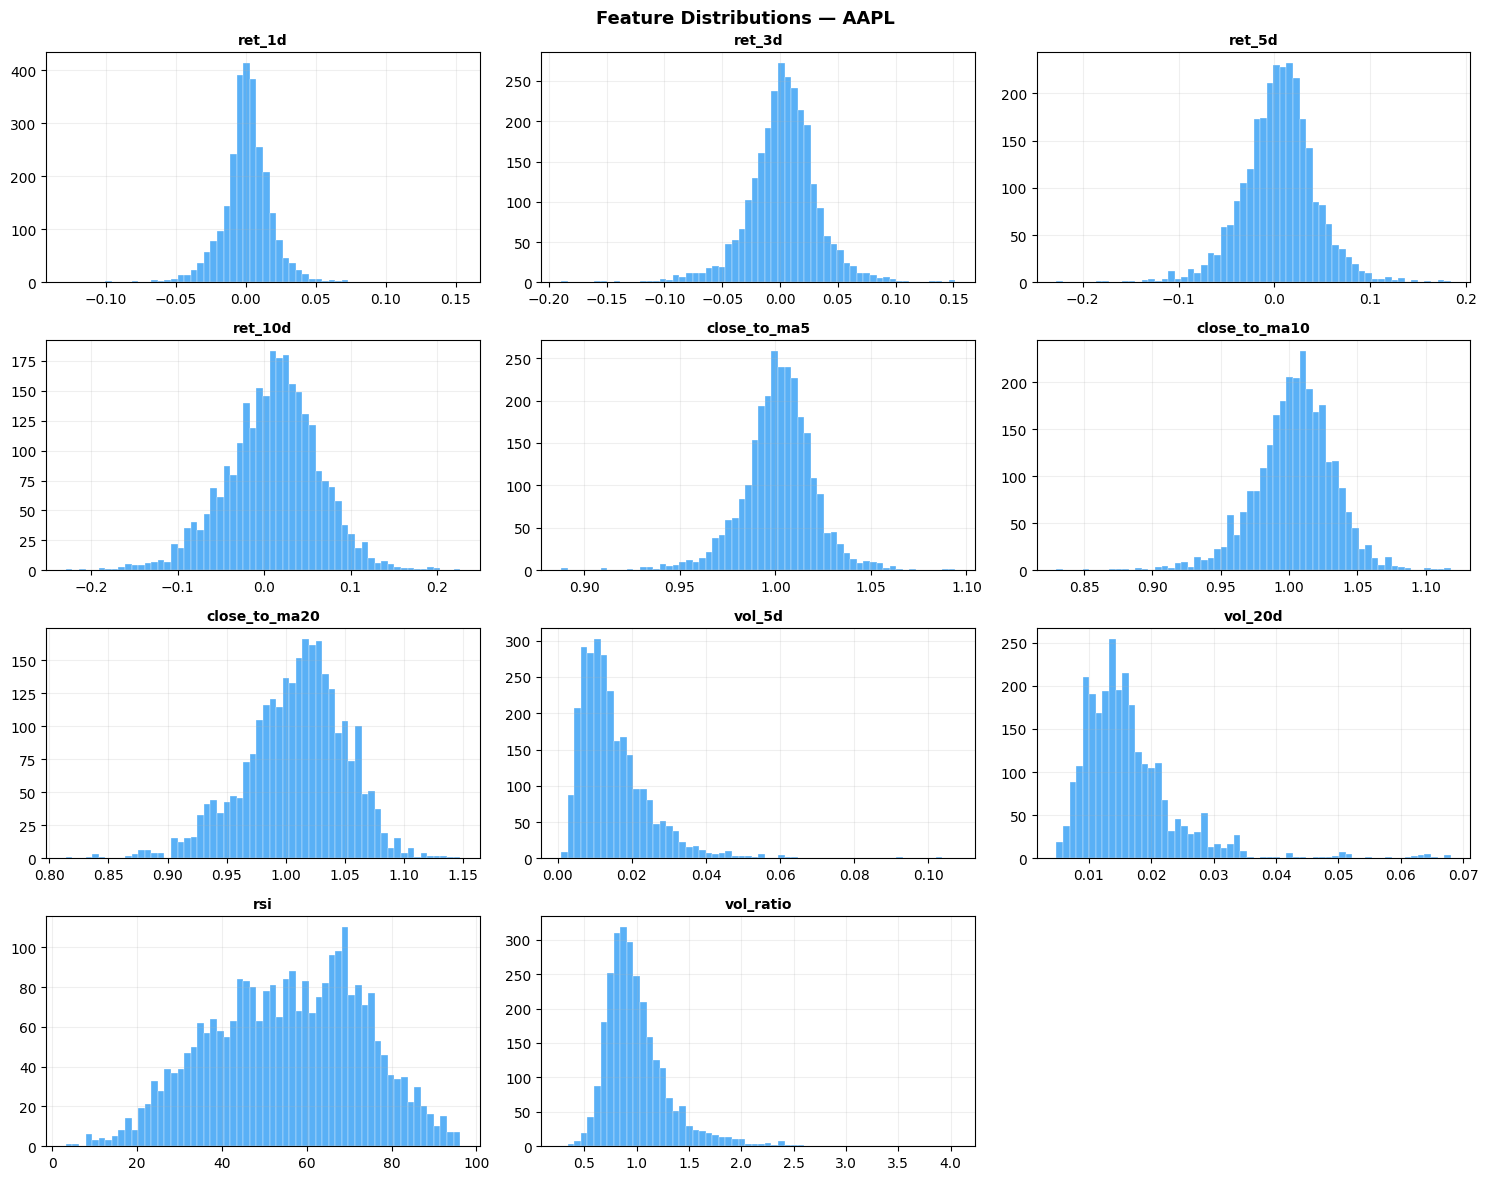

saved -> plots/02_feature_distributions.png


In [8]:
df_aapl = processed['AAPL']

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(df_aapl[col].dropna(), bins=60, color='#2196F3', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.2)

# hide the extra subplot
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — AAPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/02_feature_distributions.png')

## feature correlation heatmap

checking which features are correlated with each other — highly correlated ones carry duplicate info.

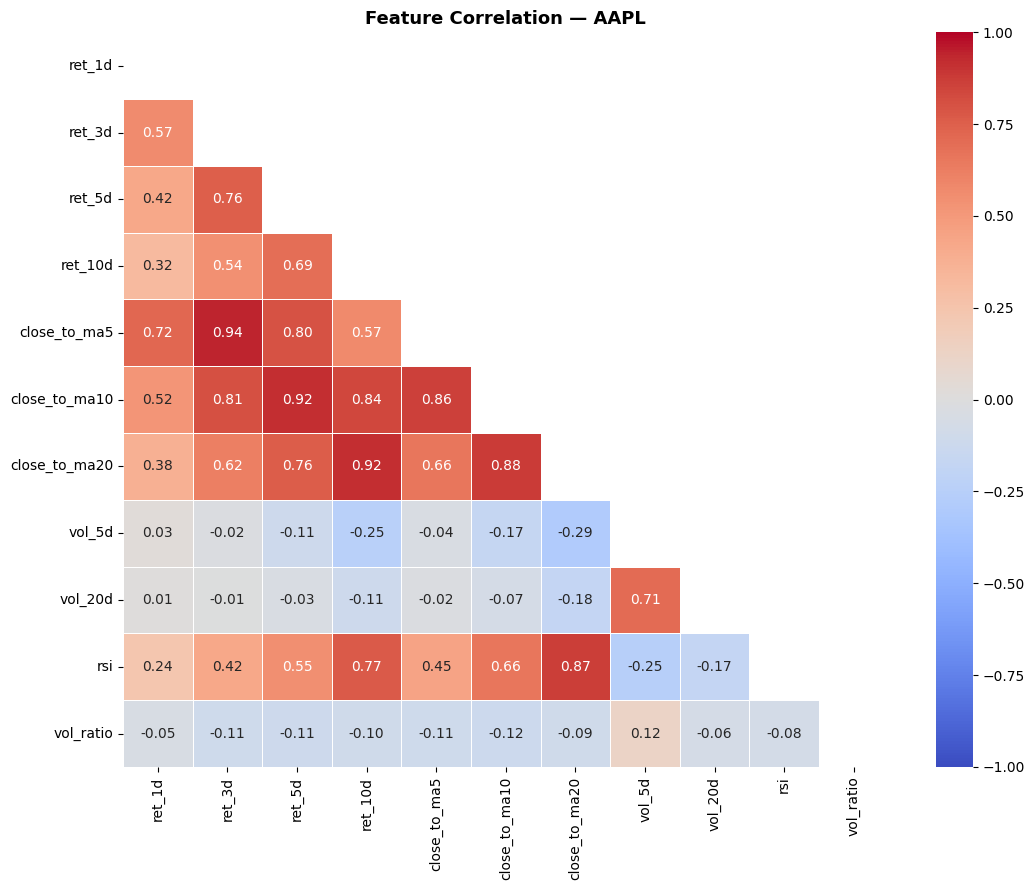

saved -> plots/02_feature_correlation.png


In [9]:
corr = df_aapl[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # only lower triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation — AAPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/02_feature_correlation.png')

## features split by label

do up days and down days actually look different in the features? if yes, the model has something to learn from.

In [10]:
up_days   = df_aapl[df_aapl['target'] == 1]
down_days = df_aapl[df_aapl['target'] == 0]

# show mean feature values for up vs down days
comparison = pd.DataFrame({
    'up days mean'   : up_days[FEATURE_COLS].mean(),
    'down days mean' : down_days[FEATURE_COLS].mean(),
})
comparison['difference'] = comparison['up days mean'] - comparison['down days mean']
comparison.round(5)

,up days mean,down days mean,difference
ret_1d,0.00056,0.00154,-0.00098
ret_3d,0.00276,0.00335,-0.00059
ret_5d,0.00493,0.00524,-0.00031
ret_10d,0.01033,0.01007,0.00027
close_to_ma5,1.00153,1.00206,-0.00053
close_to_ma10,1.00394,1.00421,-0.00027
close_to_ma20,1.00886,1.00859,0.00027
vol_5d,0.01513,0.01543,-0.00029
vol_20d,0.01646,0.01641,0.00005
rsi,55.75173,55.27528,0.47645


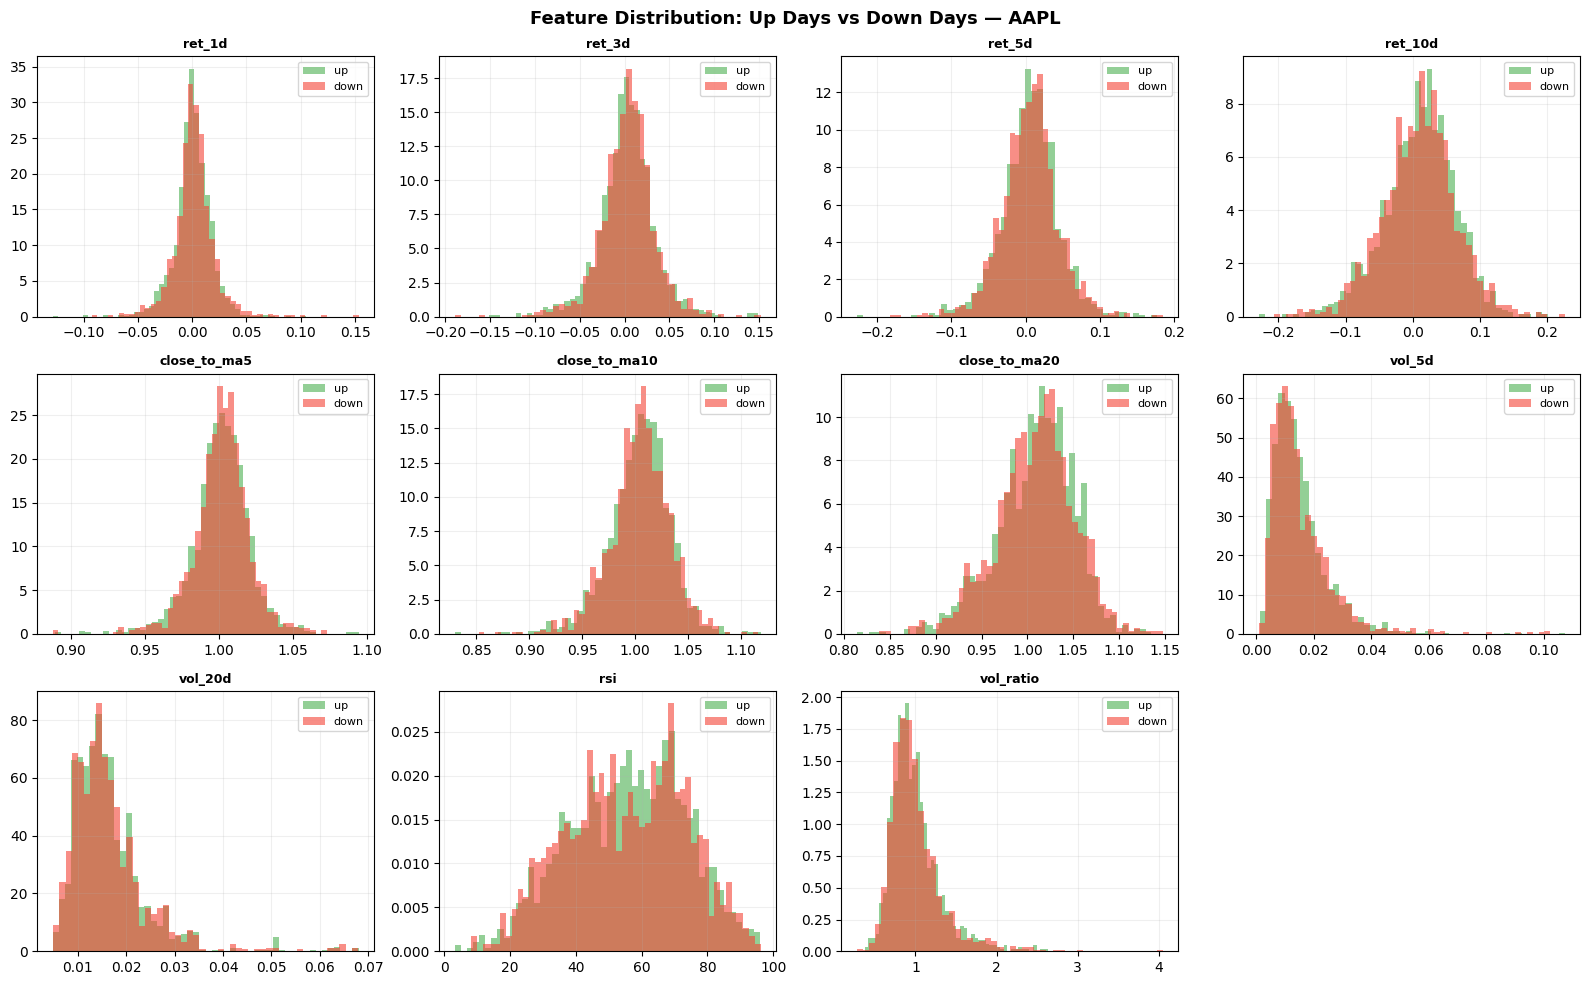

saved -> plots/02_up_vs_down.png


In [11]:
# visualise the overlap — if distributions are almost identical, that feature won't help much
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(up_days[col].dropna(),   bins=50, alpha=0.6, color='#4CAF50', label='up',   density=True)
    ax.hist(down_days[col].dropna(), bins=50, alpha=0.6, color='#F44336', label='down', density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distribution: Up Days vs Down Days — AAPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_up_vs_down.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/02_up_vs_down.png')

---

features built and saved. the overlap between up/down distributions is pretty large — which is a hint that this won't be easy to predict.  

next: `03_model_training.ipynb` — training the Random Forest and seeing how well it actually does.